# Tổng Hợp Kết Quả

In [3]:
import os, json

logs = {}
for model in ['flash', 'pro']:
    logs[model] = []
    folder_path = f"outputs/{model}"
    if os.path.exists(folder_path):
        for filename in sorted(os.listdir(folder_path)):
            if filename.startswith("log_puzzle_") and filename.endswith(".json"):
                with open(os.path.join(folder_path, filename), encoding='utf-8') as f:
                    logs[model].append(json.load(f))

for model in ['flash', 'pro']:
    if not logs[model]:
        continue
    
    print(f"\n=== Kết quả cho {model.upper()} ===")
    print(f"{'Map':>4} | {'Độ khó':<10} | {'Bước':>5} | {'Kết quả':<12} | Loại lỗi")
    print("-" * 65)
    for log in logs[model]:
        print(f"  #{log['puzzle_id']:>2} | {log['difficulty']:<10} | {log['total_steps']:>5} | {log['final_status']:<12} | {log.get('error_type', '')}")

    success = sum(1 for l in logs[model] if l['final_status'] == 'Success')
    total = len(logs[model])
    print(f"\nSolve rate: {success}/{total} ({success/total*100:.1f}%)")


=== Kết quả cho FLASH ===
 Map | Độ khó     |  Bước | Kết quả      | Loại lỗi
-----------------------------------------------------------------
  # 1 | easy       |    37 | Success      | None
  # 2 | easy       |     5 | Failed       | Incorrect Solution
  # 3 | easy       |    36 | Success      | None
  # 4 | easy       |    36 | Success      | None
  # 5 | easy       |    36 | Success      | None
  # 6 | hard       |     3 | Failed       | Incorrect Solution
  # 7 | hard       |     1 | Failed       | Incorrect Solution

Solve rate: 4/7 (57.1%)

=== Kết quả cho PRO ===
 Map | Độ khó     |  Bước | Kết quả      | Loại lỗi
-----------------------------------------------------------------
  # 1 | easy       |    36 | Success      | None
  # 2 | easy       |    36 | Success      | None
  # 3 | easy       |    36 | Success      | None
  # 4 | easy       |    37 | Success      | None
  # 5 | easy       |     5 | Failed       | Incorrect Solution
  # 6 | hard       |     2 | Failed       |

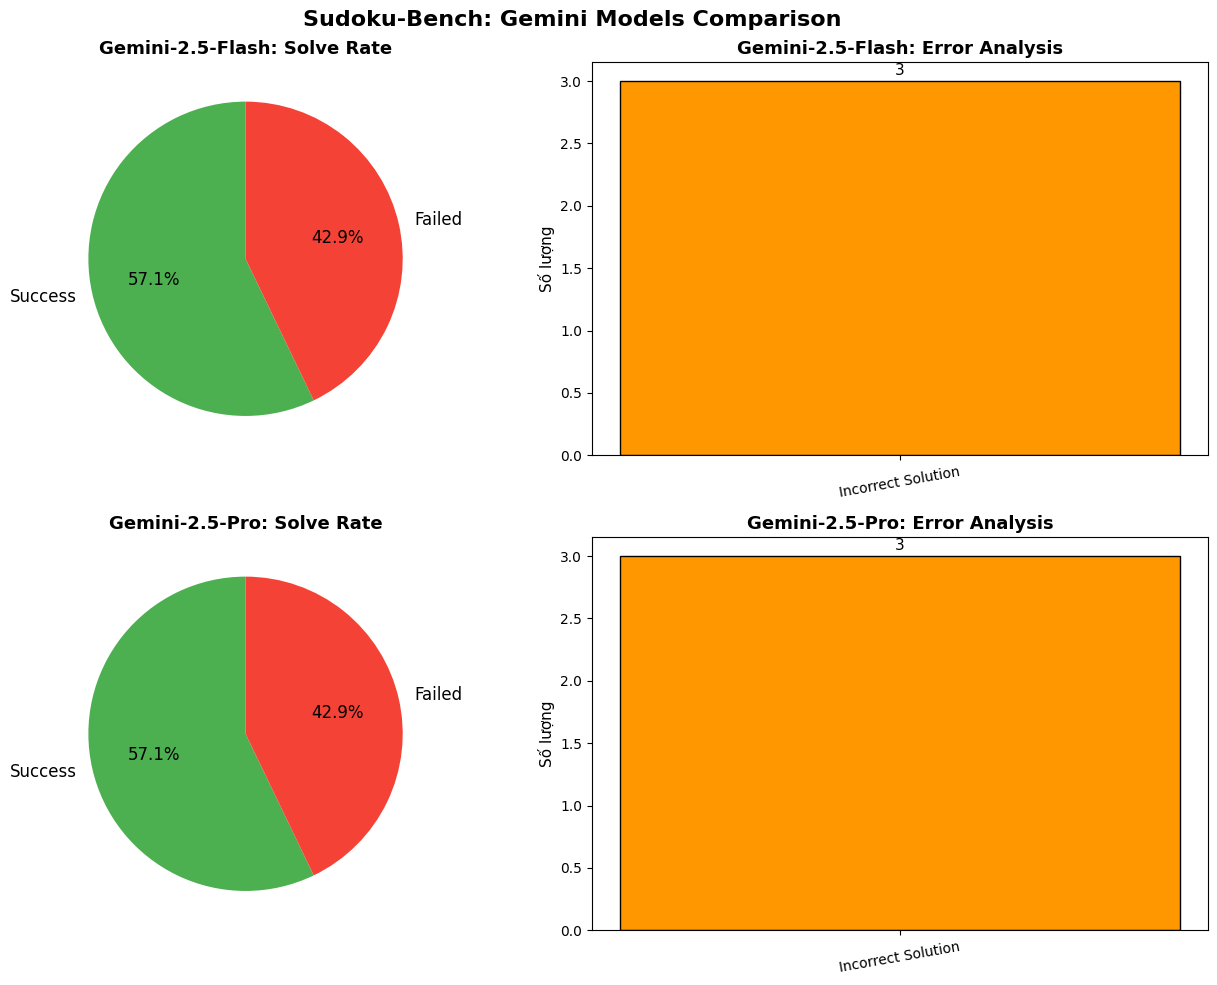

Đã lưu biểu đồ tại outputs/benchmark_results_comparison.png


In [4]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

models = [m for m in ['flash', 'pro'] if logs.get(m)]
if not models:
    print("Không có dữ liệu để vẽ biểu đồ.")
else:
    fig, axes = plt.subplots(len(models), 2, figsize=(13, 5 * len(models)))
    # Xử lý trường hợp chỉ có 1 model (axes là mảng 1D)
    if len(models) == 1:
        axes = [axes]
        
    fig.suptitle("Sudoku-Bench: Gemini Models Comparison", fontsize=16, fontweight='bold')

    model_names = {'flash': 'Gemini-2.5-Flash', 'pro': 'Gemini-2.5-Pro'}

    for i, model in enumerate(models):
        model_logs = logs[model]
        total = len(model_logs)
        success = sum(1 for l in model_logs if l['final_status'] == 'Success')
        failed = total - success
        
        # --- Biểu đồ 1: Solve Rate ---
        axes[i][0].pie([success, failed], labels=['Success', 'Failed'],
                    colors=['#4CAF50', '#F44336'], autopct='%1.1f%%',
                    startangle=90, textprops={'fontsize': 12})
        axes[i][0].set_title(f"{model_names.get(model, model)}: Solve Rate", fontsize=13, fontweight='bold')

        # --- Biểu đồ 2: Error Analysis ---
        errors = {}
        for log in model_logs:
            if log['final_status'] != 'Success':
                e = log.get('error_type', 'Unknown')
                errors[e] = errors.get(e, 0) + 1

        if errors:
            bars = axes[i][1].bar(errors.keys(), errors.values(),
                              color=['#FF9800', '#2196F3', '#9C27B0', '#F44336'],
                              edgecolor='black')
            for bar in bars:
                axes[i][1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                            int(bar.get_height()), ha='center', fontsize=11)
            axes[i][1].set_title(f"{model_names.get(model, model)}: Error Analysis", fontsize=13, fontweight='bold')
            axes[i][1].set_ylabel("Số lượng", fontsize=11)
            axes[i][1].tick_params(axis='x', rotation=10)
        else:
            axes[i][1].text(0.5, 0.5, 'All Correct!', ha='center', va='center',
                        fontsize=16, transform=axes[i][1].transAxes)
            axes[i][1].set_title(f"{model_names.get(model, model)}: Error Analysis", fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.savefig('outputs/benchmark_results_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Đã lưu biểu đồ tại outputs/benchmark_results_comparison.png")

# Phân Tích Chuyên Sâu
So sánh chi tiết hiệu suất giữa các mô hình dựa trên độ khó và số bước thực hiện.

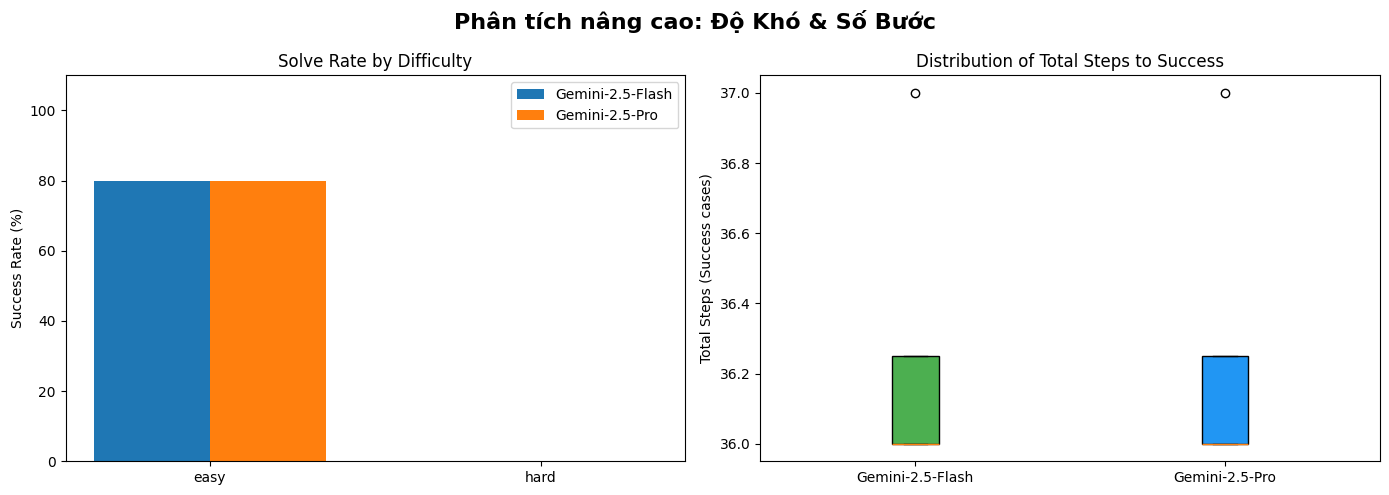

Đã lưu biểu đồ phân tích sâu tại outputs/advanced_analysis.png


In [5]:
import numpy as np

if models:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Phân tích nâng cao: Độ Khó & Số Bước", fontsize=16, fontweight='bold')

    # --- Biểu đồ 3: Tỷ lệ giải đúng theo độ khó ---
    difficulties = sorted(list(set(log['difficulty'] for log in logs[models[0]])))
    
    bar_width = 0.35
    x = np.arange(len(difficulties))
    
    for i, model in enumerate(models):
        success_rates = []
        for diff in difficulties:
            diff_logs = [l for l in logs[model] if l['difficulty'] == diff]
            if diff_logs:
                success = sum(1 for l in diff_logs if l['final_status'] == 'Success')
                success_rates.append(success / len(diff_logs) * 100)
            else:
                success_rates.append(0)
                
        axes[0].bar(x + i*bar_width, success_rates, bar_width, label=model_names.get(model, model))

    axes[0].set_ylabel('Success Rate (%)')
    axes[0].set_title('Solve Rate by Difficulty')
    axes[0].set_xticks(x + bar_width/2 if len(models) > 1 else x)
    axes[0].set_xticklabels(difficulties)
    axes[0].legend()
    axes[0].set_ylim(0, 110)

    # --- Biểu đồ 4: Phân bố số bước (Boxplot) ---
    step_data = []
    labels = []
    for model in models:
        # Lấy số bước của các test case chạy thành công
        steps = [l['total_steps'] for l in logs[model] if l['final_status'] == 'Success']
        step_data.append(steps if steps else [0])
        labels.append(model_names.get(model, model))
        
    bplot = axes[1].boxplot(step_data, patch_artist=True, tick_labels=labels)
    colors = ['#4CAF50', '#2196F3']
    for patch, color in zip(bplot['boxes'], colors[:len(models)]):
        patch.set_facecolor(color)
        
    axes[1].set_ylabel('Total Steps (Success cases)')
    axes[1].set_title('Distribution of Total Steps to Success')
    
    plt.tight_layout()
    plt.savefig('outputs/advanced_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Đã lưu biểu đồ phân tích sâu tại outputs/advanced_analysis.png")